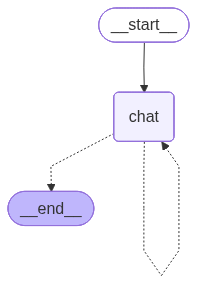


User:  hi?


Hello! How can I help you today?


User:  say long


**A Journey Through the Whispering Library**

---

### Prologue

In the heart of an ancient city, where cobblestones remember every footstep and the wind carries stories from centuries past, there stood a library unlike any other. It was not built of stone or timber but of memory itself—books


User:  1 + 1 = ?


The sum is **2**.


User:  거기에 2를 더하면?


`1 + 1 = 2`에 2를 더하면 **4**가 됩니다.

In [ ]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(
    temperature=0.0, 
    base_url="http://127.0.0.1:1234/v1", 
    api_key="not-needed", 
    model="openai/gpt-oss-20b"
)
llm_short = llm.bind(max_tokens=100)

class ChatLog(TypedDict):
    user_message: str
    assistant: str

class ChatLogState(TypedDict):
    logs: Annotated[List[ChatLog], operator.add]

def chat_node(state: ChatLogState) -> Command[Literal["chat", END]]:
    user_message = interrupt("wait user message")

    prompt = ""
    for log in state['logs']:
        prompt += f"user_message: {log['user_message']}\nassistant: {log['assistant']}\n"
    prompt += f"user_message: {user_message}"
    
    assistant = llm_short.invoke(prompt)

    chat_log = ChatLog(user_message = user_message, assistant = assistant.content)
    return Command(
        update = ChatLogState(logs = [chat_log]),
        goto = "chat"
    )

memory = InMemorySaver()

builder = StateGraph(ChatLogState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

config = {"configurable": {"thread_id": "1"}}
result = graph.invoke(ChatLogState(userMessage = None, generation = None), config)
while True:
    snapshot = graph.get_state(config)
    if snapshot.next:
        user_input = input("\nUser: ")
        if user_input.lower() in ["quit", "exit"]:
            break
        for msg, metadata in graph.stream(Command(resume=user_input), config, stream_mode="messages"):
            if msg.content:
                print(msg.content, end="", flush=True)